# Average Solar Generation vs Consumption in a Day

This notebook provides a quick exploratory analysis of average solar energy generation and household energy consumption throughout the day using the `fact_solar_hourly` and `fact_weather_hourly` datasets.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

In [4]:
df_weather_codes = pd.read_csv('../assets/datasets/dim_weather_codes.csv')
df_solar_hourly = pd.read_csv('../assets/datasets/fact_solar_hourly.csv')
df_weather_hourly = pd.read_csv('../assets/datasets/fact_weather_hourly.csv')

In [6]:
query = """
select 
    s.date,
    s.hour_ts,
    s.generation_kwh,
    s.consumption_kwh,
    s.grid_feed_in_kwh,
    s.grid_purchase_kwh,
    s.charge_kwh,
    s.discharge_kwh,
    s.battery_soc_eoh,
    w.relative_humidity_2m,
    w.wind_speed_10m,
    w.is_day,
    w.sunshine_duration,
    w.temperature_2m,
    w.cloud_cover,
    w.rain,
    wc.description as weather_description
from df_solar_hourly s
join df_weather_hourly w
    on s.date = w.date
    and s.hour_ts = w.hour_ts
join df_weather_codes wc
    on w.weather_code = wc.weather_code
"""

hourly_df = duckdb.query(query).to_df()
hourly_df.head()

,date,hour_ts,generation_kwh,consumption_kwh,grid_feed_in_kwh,grid_purchase_kwh,charge_kwh,discharge_kwh,battery_soc_eoh,relative_humidity_2m,wind_speed_10m,is_day,sunshine_duration,temperature_2m,cloud_cover,rain,weather_description
0,2026-02-01,2026-02-02 00:00:00+08,0.0,0.833083,NaN,0.00275,NaN,0.896000,66.0,64.824158,20.008356,False,0.0,24.450001,100.0,0.0,Clouds generally forming or developing
1,2026-02-01,2026-02-02 01:00:00+08,0.0,0.831583,NaN,NaN,NaN,0.896500,62.0,69.004318,21.158232,False,0.0,24.299999,100.0,0.0,Clouds generally forming or developing
2,2026-02-01,2026-02-02 02:00:00+08,0.0,0.735417,NaN,NaN,NaN,0.795250,58.0,74.965202,16.459915,False,0.0,23.650000,99.0,0.0,Clouds generally forming or developing
3,2026-02-01,2026-02-02 03:00:00+08,0.0,0.679750,NaN,NaN,NaN,0.736333,54.0,72.666550,17.593100,False,0.0,23.700001,91.0,0.0,Clouds generally forming or developing
4,2026-02-01,2026-02-02 04:00:00+08,0.0,0.731667,NaN,NaN,NaN,0.792000,50.0,67.412933,19.770523,False,0.0,23.850000,48.0,0.0,Clouds generally dissolving or becoming less d...


In [7]:
sns.set_theme(style="whitegrid")

hourly_df['hour_ts'] = pd.to_datetime(hourly_df['hour_ts'])
hourly_df['hour'] = hourly_df['hour_ts'].dt.hour

avg_hourly = (
    hourly_df
    .groupby('hour', as_index=False)
    [['generation_kwh', 'consumption_kwh', 'grid_feed_in_kwh', 'grid_purchase_kwh']]
    .mean()
)

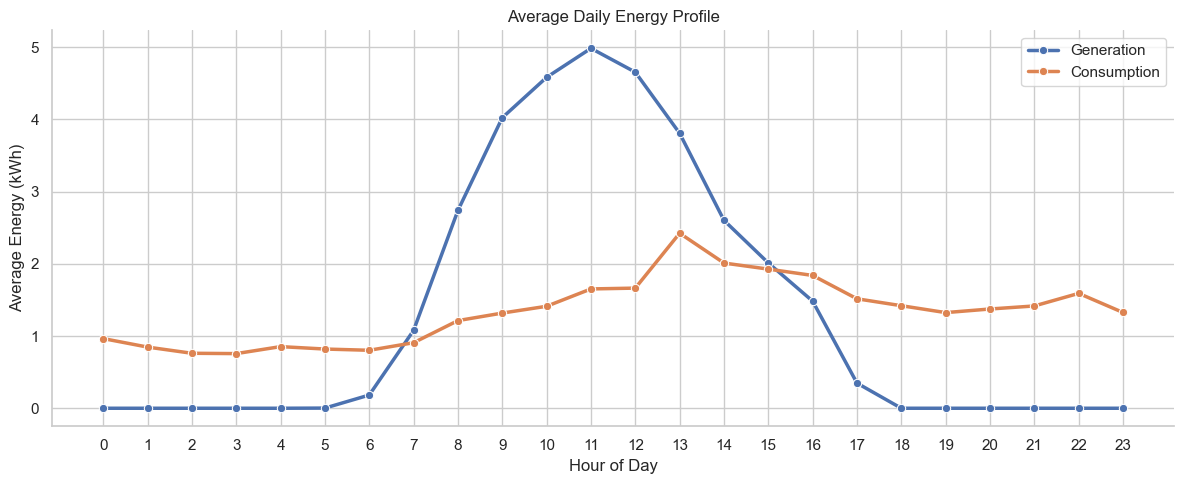

In [8]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=avg_hourly,
    x='hour',
    y='generation_kwh',
    marker='o',
    linewidth=2.5,
    label='Generation'
)

sns.lineplot(
    data=avg_hourly,
    x='hour',
    y='consumption_kwh',
    marker='o',
    linewidth=2.5,
    label='Consumption'
)

plt.title('Average Daily Energy Profile')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy (kWh)')
plt.xticks(range(0, 24))
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

### Generation observations:
- Solar generation begins around 6 AM, increases rapidly after sunrise, and peaks near 11 AM at approximately 5 kWh.
- Generation remains high during late morning and early afternoon before declining steadily toward sunset.
- By around 6 PM, solar generation drops to nearly zero, indicating the end of daylight production.

### Consumption observations:
- Consumption gradually increases during daytime hours and reaches its highest point around 1 PM, peaking near 2.4 kWh.
- Evening consumption remains elevated even after solar generation declines, suggesting continued household energy demand after sunset.